<a href="https://colab.research.google.com/github/Jishafranklin/Parallel-Project-HR-Employee-Attrition-Preprocessing/blob/adil-feature-scaling/notebooks/HR_Employee_Attrition_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading & Initial Exploration
## Team Member: Jisha

### Purpose
This section loads the HR Employee Attrition dataset and performs initial exploration to understand:
- Dataset structure (rows, columns, data types)
- Quality of data (missing values, duplicates)
- Target variable distribution
- Basic statistical properties
- Which columns are numeric vs categorical

### Dataset Source
[IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options to see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Saving WA_Fn-UseC_-HR-Employee-Attrition (1).csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv
Dataset loaded successfully!
Shape: (1470, 35)


In [ ]:
# Check number of rows and columns
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 1470 rows and 35 columns


In [ ]:
# Check data types of each column
print("Data Types:\n")
print(df.dtypes)

Data Types:

Age                         int64
Attrition                  object
BusinessTravel             object
DailyRate                   int64
Department                 object
                            ...  
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrManager        int64
Length: 35, dtype: object


In [ ]:
# Get comprehensive info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Statistical summary of numeric columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Check the target variable - Attrition

print("Attrition Value Counts:")
print(df['Attrition'].value_counts())

print("\nAttrition Percentages:")
print((df['Attrition'].value_counts(normalize=True) * 100).round(2))


Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentages:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_cols.tolist())




Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [ ]:
# Display unique values for each categorical column
for col in categorical_cols:
    print("\n",col, ":", df[col].unique())


 Attrition : ['Yes' 'No']

 BusinessTravel : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

 Department : ['Sales' 'Research & Development' 'Human Resources']

 EducationField : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

 Gender : ['Female' 'Male']

 JobRole : ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

 MaritalStatus : ['Single' 'Married' 'Divorced']

 Over18 : ['Y']

 OverTime : ['Yes' 'No']


In [ ]:
# Check the number of unique values in each column
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
...,...
WorkLifeBalance,4
YearsAtCompany,37
YearsInCurrentRole,19
YearsSinceLastPromotion,16


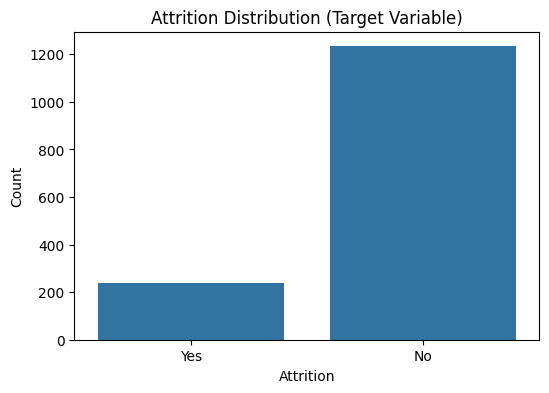

In [ ]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution (Target Variable)')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

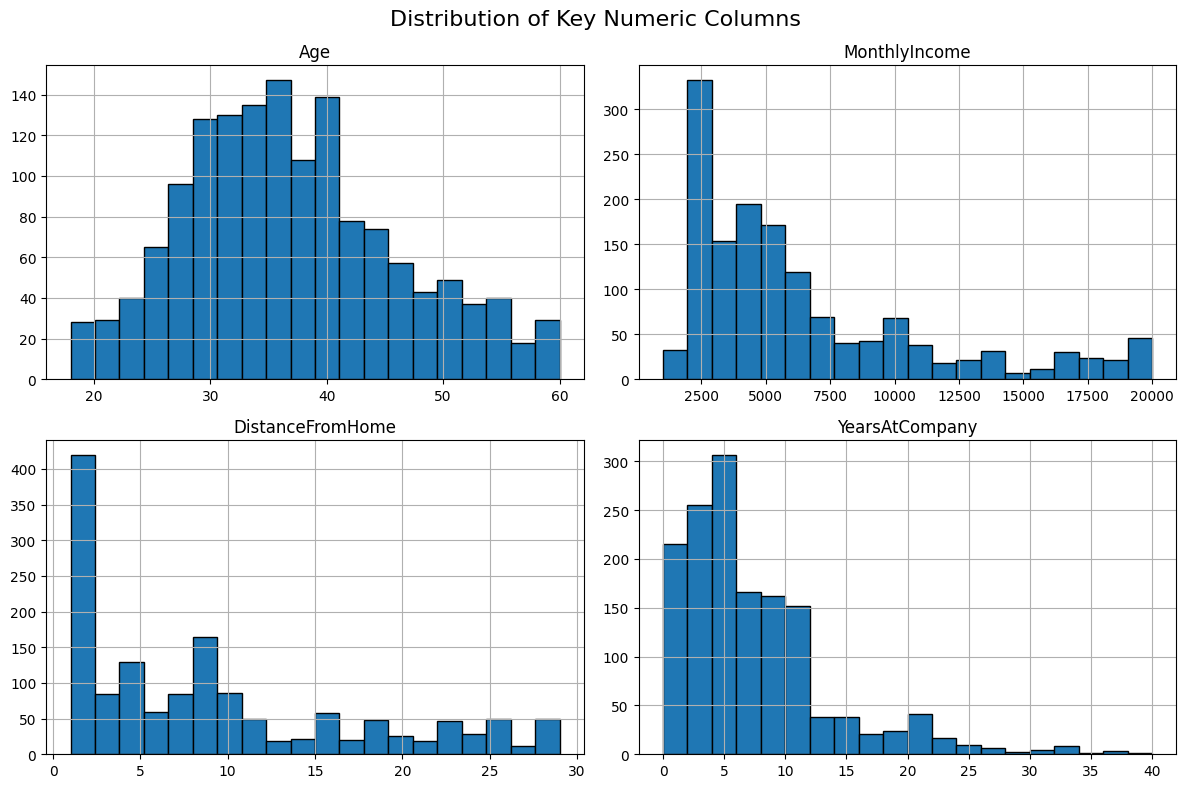

In [ ]:
# Quick histogram of key numeric columns
numeric_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']
df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle('Distribution of Key Numeric Columns', size=16)
plt.tight_layout()
plt.show()

## 📌 Initial Observations

### Dataset Overview
- **Total Records:** 1,470 employees
- **Total Features:** 35 columns
- **Target Variable:** `Attrition` (Yes = employee left, No = employee stayed)

### Data Types
- **Numeric Columns (int64):** Age, DailyRate, DistanceFromHome, Education, EmployeeNumber, EnvironmentSatisfaction, HourlyRate, JobInvolvement, JobLevel, JobSatisfaction, MonthlyIncome, MonthlyRate, NumCompaniesWorked, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager
- **Categorical Columns (object):** Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, Over18, OverTime

### Target Variable Analysis
- **Attrition 'No':** ~1,233 employees (83.9%)
- **Attrition 'Yes':** ~237 employees (16.1%)
- **Observation:** There is significant class imbalance. This should be considered during modeling.

### Initial Data Quality Observation

- `df.info()` shows that all 1,470 records are non-null.
- A detailed missing-value analysis and Duplicate and data consistency checks will be performed by the respective team members.



### Key Numeric Column Ranges
- **Age:** 18 to 60 years
- **MonthlyIncome:** ~1,000 to ~20,000
- **DistanceFromHome:** 1 to 29 miles
- **YearsAtCompany:** 0 to 40 years
- **TotalWorkingYears:** 0 to 40 years

### Next Steps
- Gouri will perform missing value analysis
- Meenaskshi will handle duplicates & data consistency


### Conclusion

The initial exploration provides an understanding of the dataset structure, variable types, target distribution, and basic numerical distributions. Further preprocessing steps will be performed by the respective team members.

# Handling Missing Values

**Dataset:** IBM HR Analytics Employee Attrition & Performance

**Contribution:** Gouri

## Objective
To identify and handle missing values in the dataset.

In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
...,...
WorkLifeBalance,0
YearsAtCompany,0
YearsInCurrentRole,0
YearsSinceLastPromotion,0


In [ ]:
df.isna().mean() * 100

,0
Age,0.0
Attrition,0.0
BusinessTravel,0.0
DailyRate,0.0
Department,0.0
...,...
WorkLifeBalance,0.0
YearsAtCompany,0.0
YearsInCurrentRole,0.0
YearsSinceLastPromotion,0.0


In [ ]:
df.isna().sum().sum()

np.int64(0)

## Conclusion

The dataset was analyzed for missing values. No missing values were found, so no imputation or deletion was required. The dataset is ready for the next preprocessing stage.


## 3. Handling Duplicates and Data Consistency

**Team Member: Meenakshi**

### Objective

To identify duplicate records, check the uniqueness of employee identifiers,
remove constant columns that do not provide useful information, and verify
the consistency of categorical values before further preprocessing.

In [3]:
# Check for duplicate EmployeeNumber values

duplicate_employee_numbers = df["EmployeeNumber"].duplicated().sum()

print("Number of duplicate EmployeeNumber values:", duplicate_employee_numbers)

Number of duplicate EmployeeNumber values: 0


In [4]:
# Check for duplicate EmployeeNumber values

duplicate_employee_numbers = df["EmployeeNumber"].duplicated().sum()

print("Number of duplicate EmployeeNumber values:", duplicate_employee_numbers)

Number of duplicate EmployeeNumber values: 0


In [5]:
# Identify columns with only one unique value

constant_columns = df.nunique()[df.nunique() == 1]

print("Constant columns:")
print(constant_columns)

Constant columns:
EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64


In [6]:
# Remove constant columns because they do not provide useful information

df = df.drop(columns=constant_columns.index)

print("Columns removed:", list(constant_columns.index))
print("Shape after removing constant columns:", df.shape)

Columns removed: ['EmployeeCount', 'Over18', 'StandardHours']
Shape after removing constant columns: (1470, 32)


In [7]:
# Check categorical columns for consistency

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical value consistency check:")

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Categorical value consistency check:

Attrition:
['Yes' 'No']

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department:
['Sales' 'Research & Development' 'Human Resources']

EducationField:
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender:
['Female' 'Male']

JobRole:
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus:
['Single' 'Married' 'Divorced']

OverTime:
['Yes' 'No']


### Conclusion

The dataset contains no duplicate rows, and all EmployeeNumber values are unique. Three constant columns :EmployeeCount, Over18, and StandardHours were identified and removed because they do not provide useful information for further analysis. The categorical variables were also checked for consistency, and no major inconsistencies were found.

After removing the constant columns, the dataset contains 1,470 rows and 32 columns.

# Data Encoding

**Dataset:** IBM HR Analytics Employee Attrition & Performance

**Contribution:** Amjed

## Objective
To convert all categorical text variables into numeric representations suitable for machine learning algorithms without introducing false mathematical hierarchies or multicollinearity

In [ ]:
# data encoding
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Label Encoding
le = LabelEncoder()
columns_encoding = ["Attrition", "Gender", "OverTime", "Over18"]

for col in columns_encoding:
  df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,0,94,3,2,Sales Executive,4,Single,5993,19479,8,0,1,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,1,61,2,2,Research Scientist,2,Married,5130,24907,1,0,0,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,1,92,2,1,Laboratory Technician,3,Single,2090,2396,6,0,1,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,0,56,3,1,Research Scientist,3,Married,2909,23159,1,0,1,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,1,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,0,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
# OneHotencoding

df = pd.get_dummies(df, columns=[ "BusinessTravel","Department","EducationField","JobRole","MaritalStatus"], dtype=int)

In [ ]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,3,2,4,5993,19479,8,0,1,11,3,1,80,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,2,2,2,5130,24907,1,0,0,23,4,4,80,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,2,1,3,2090,2396,6,0,1,15,3,2,80,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,3,1,3,2909,23159,1,0,1,11,3,3,80,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,3,1,2,3468,16632,9,0,0,12,3,4,80,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0


##Categorical Feature Breakdown
* Total Categorical Features: 9 columns (Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, Over18, OverTime)

* Binary Target Variable: Attrition ('Yes', 'No')

* Binary Attributes: Gender ('Female', 'Male'), OverTime ('Yes', 'No')

* Ordinal Attribute: BusinessTravel ('Non-Travel', 'Travel_Rarely', 'Travel_Frequently')

* Nominal Multi-class Attributes: Department (3), EducationField (6), JobRole (9), MaritalStatus (3)

* Constant / Zero-Variance Attribute: Over18 (only 'Y')

## Next Steps:

* Hand over the encoded DataFrame to Feature Engineering & Extraction to eliminate uninformative rate IDs and build composite satisfaction/tenure metrics.

## Conclusion
The categorical data encoding phase successfully transforms all non-numeric variables in the IBM HR Analytics Employee Attrition & Performance dataset into an algorithm-ready numerical format while maintaining statistical integrity

# 7. Shahin — Feature Engineering & Correlation Analysis

This stage focuses on improving the dataset by creating meaningful derived features, removing irrelevant or redundant columns, and analyzing relationships between numerical features.

### Objectives
- Create useful engineered features.
- Remove irrelevant and redundant columns.
- Analyze correlations between numerical features.
- Visualize correlations using a heatmap.
- Prepare the feature-engineered dataset for Adil's feature scaling and normalization stage.

## 7.1 Feature Engineering

Feature engineering creates new variables from existing features to provide additional information that may be useful for analysis and machine learning.

Two meaningful features are created:

- **TenureRatio:** Represents the proportion of an employee's total working experience spent at the current company.
- **IncomePerYearExperience:** Represents monthly income relative to the employee's total working experience.

In [ ]:
# Create TenureRatio

df["TenureRatio"] = (
    df["YearsAtCompany"] /
    df["TotalWorkingYears"].replace(0, np.nan)
)

# Replace undefined values caused by zero experience
df["TenureRatio"] = df["TenureRatio"].fillna(0)

# Display the new feature
df[[
    "YearsAtCompany",
    "TotalWorkingYears",
    "TenureRatio"
]].head()

,YearsAtCompany,TotalWorkingYears,TenureRatio
0,6,8,0.750000
1,10,10,1.000000
2,0,7,0.000000
3,8,8,1.000000
4,2,6,0.333333


In [ ]:
# Create IncomePerYearExperience

df["IncomePerYearExperience"] = (
    df["MonthlyIncome"] /
    df["TotalWorkingYears"].replace(0, np.nan)
)

# Replace undefined values caused by zero experience
df["IncomePerYearExperience"] = df[
    "IncomePerYearExperience"
].fillna(0)

# Display the new feature
df[[
    "MonthlyIncome",
    "TotalWorkingYears",
    "IncomePerYearExperience"
]].head()

,MonthlyIncome,TotalWorkingYears,IncomePerYearExperience
0,5993,8,749.125000
1,5130,10,513.000000
2,2090,7,298.571429
3,2909,8,363.625000
4,3468,6,578.000000


## 7.2 Removing Irrelevant and Redundant Features

Some columns do not provide useful predictive information and can be removed before further preprocessing.

The following columns are removed:

- **EmployeeCount** — constant value for all employees.
- **StandardHours** — constant value for all employees.
- **Over18** — contains only one category and therefore has no useful variation.
- **EmployeeNumber** — unique employee identifier and not a meaningful predictive feature.

Removing these columns reduces unnecessary information and prevents employee identifiers from influencing the analysis.

In [ ]:
# Remove irrelevant and redundant columns

columns_to_drop = [
    "EmployeeCount",
    "StandardHours",
    "Over18",
    "EmployeeNumber"
]

df_fe = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Removed columns:")
print(columns_to_drop)

print("\nShape after feature selection:", df_fe.shape)

Removed columns:
['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']

Shape after feature selection: (1470, 52)


## 7.3 Final Feature Check

The feature-engineered dataset is checked to verify that the newly created features are present and that the irrelevant columns have been removed.

In [ ]:
# Display final feature list

print("Final features after feature engineering:\n")

for i, column in enumerate(df_fe.columns, start=1):
    print(f"{i}. {column}")

Final features after feature engineering:

1. Age
2. Attrition
3. DailyRate
4. DistanceFromHome
5. Education
6. EnvironmentSatisfaction
7. Gender
8. HourlyRate
9. JobInvolvement
10. JobLevel
11. JobSatisfaction
12. MonthlyIncome
13. MonthlyRate
14. NumCompaniesWorked
15. OverTime
16. PercentSalaryHike
17. PerformanceRating
18. RelationshipSatisfaction
19. StockOptionLevel
20. TotalWorkingYears
21. TrainingTimesLastYear
22. WorkLifeBalance
23. YearsAtCompany
24. YearsInCurrentRole
25. YearsSinceLastPromotion
26. YearsWithCurrManager
27. BusinessTravel_Non-Travel
28. BusinessTravel_Travel_Frequently
29. BusinessTravel_Travel_Rarely
30. Department_Human Resources
31. Department_Research & Development
32. Department_Sales
33. EducationField_Human Resources
34. EducationField_Life Sciences
35. EducationField_Marketing
36. EducationField_Medical
37. EducationField_Other
38. EducationField_Technical Degree
39. JobRole_Healthcare Representative
40. JobRole_Human Resources
41. JobRole_Laborator

In [ ]:
# Verify that the removed columns are no longer present

removed_columns_check = [
    "EmployeeCount",
    "StandardHours",
    "Over18",
    "EmployeeNumber"
]

print("Checking removed columns:")

for column in removed_columns_check:
    print(f"{column}: {column in df_fe.columns}")

Checking removed columns:
EmployeeCount: False
StandardHours: False
Over18: False
EmployeeNumber: False


## 7.4 Correlation Analysis

Correlation analysis is used to understand the relationships between numerical features in the feature-engineered dataset.

The correlation coefficient ranges from -1 to +1:

- **+1** indicates a strong positive relationship.
- **-1** indicates a strong negative relationship.
- **0** indicates little or no linear relationship.

The correlation matrix and heatmap are used to identify relationships between features and support feature selection decisions.

In [ ]:
# Calculate correlation matrix

correlation_matrix = df_fe.corr(
    numeric_only=True
)

correlation_matrix.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,TenureRatio,IncomePerYearExperience
Age,1.000000,-0.159205,0.010661,-0.001686,0.208034,0.010146,-0.036311,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.028062,0.003634,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,-0.011215,-0.024743,0.028791,0.020523,0.017883,-0.027549,0.001696,0.016824,0.038162,-0.006354,-0.041466,-0.027604,0.098825,-0.029856,-0.143176,0.294248,0.049726,0.185891,-0.146518,-0.002001,-0.175785,0.033120,0.083919,-0.119185,-0.340425,-0.314492
Attrition,-0.159205,1.000000,-0.056652,0.077924,-0.031373,-0.103369,0.029453,-0.006846,-0.130016,-0.169105,-0.103481,-0.159840,0.015170,0.043494,0.246118,-0.013478,0.002889,-0.045872,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199,-0.074457,0.115143,-0.049538,0.016832,-0.085293,0.080855,0.036466,-0.032703,0.055781,-0.046999,-0.017898,0.069355,-0.078696,0.036215,0.098290,-0.083316,-0.082994,-0.088870,-0.000360,0.019774,0.157234,-0.087716,-0.090984,0.175419,-0.016244,0.147661
DailyRate,0.010661,-0.056652,1.000000,-0.004985,-0.016806,0.018355,-0.011716,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.009135,0.022704,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,0.012096,-0.011776,0.002078,-0.026726,0.014871,-0.003616,-0.043144,0.004028,-0.064449,0.034202,-0.003893,0.030869,0.040141,-0.021156,-0.006728,-0.013224,-0.005302,-0.000021,-0.002624,-0.000513,0.005375,0.037080,0.040035,-0.075835,-0.031627,-0.000616
DistanceFromHome,-0.001686,0.077924,-0.004985,1.000000,0.021042,-0.016075,-0.001851,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.025514,0.040235,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,0.023605,0.005081,-0.020116,-0.012901,-0.008117,0.014085,-0.002624,-0.024499,0.039294,0.013486,-0.007969,-0.014802,0.022916,-0.024089,0.012369,-0.039190,0.011848,-0.022351,-0.010986,0.030761,-0.015994,-0.005440,0.030232,-0.027445,0.014031,-0.011034
Education,0.208034,-0.031373,-0.016806,0.021042,1.000000,-0.027128,-0.016547,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.020322,-0.011111,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,0.004524,-0.008292,0.004126,0.011435,-0.018604,0.014215,0.026479,0.013184,0.072405,-0.072335,0.038043,-0.026742,0.024270,-0.005295,-0.063566,0.028453,-0.005290,0.049694,0.000709,0.053398,-0.091465,-0.002439,-0.001865,0.004168,-0.115422,-0.104432


### Correlation Heatmap

The heatmap provides a visual representation of the correlation between numerical features.

Strong positive or negative correlations can indicate that two variables contain related information. These relationships should be considered when selecting features for subsequent machine learning stages.

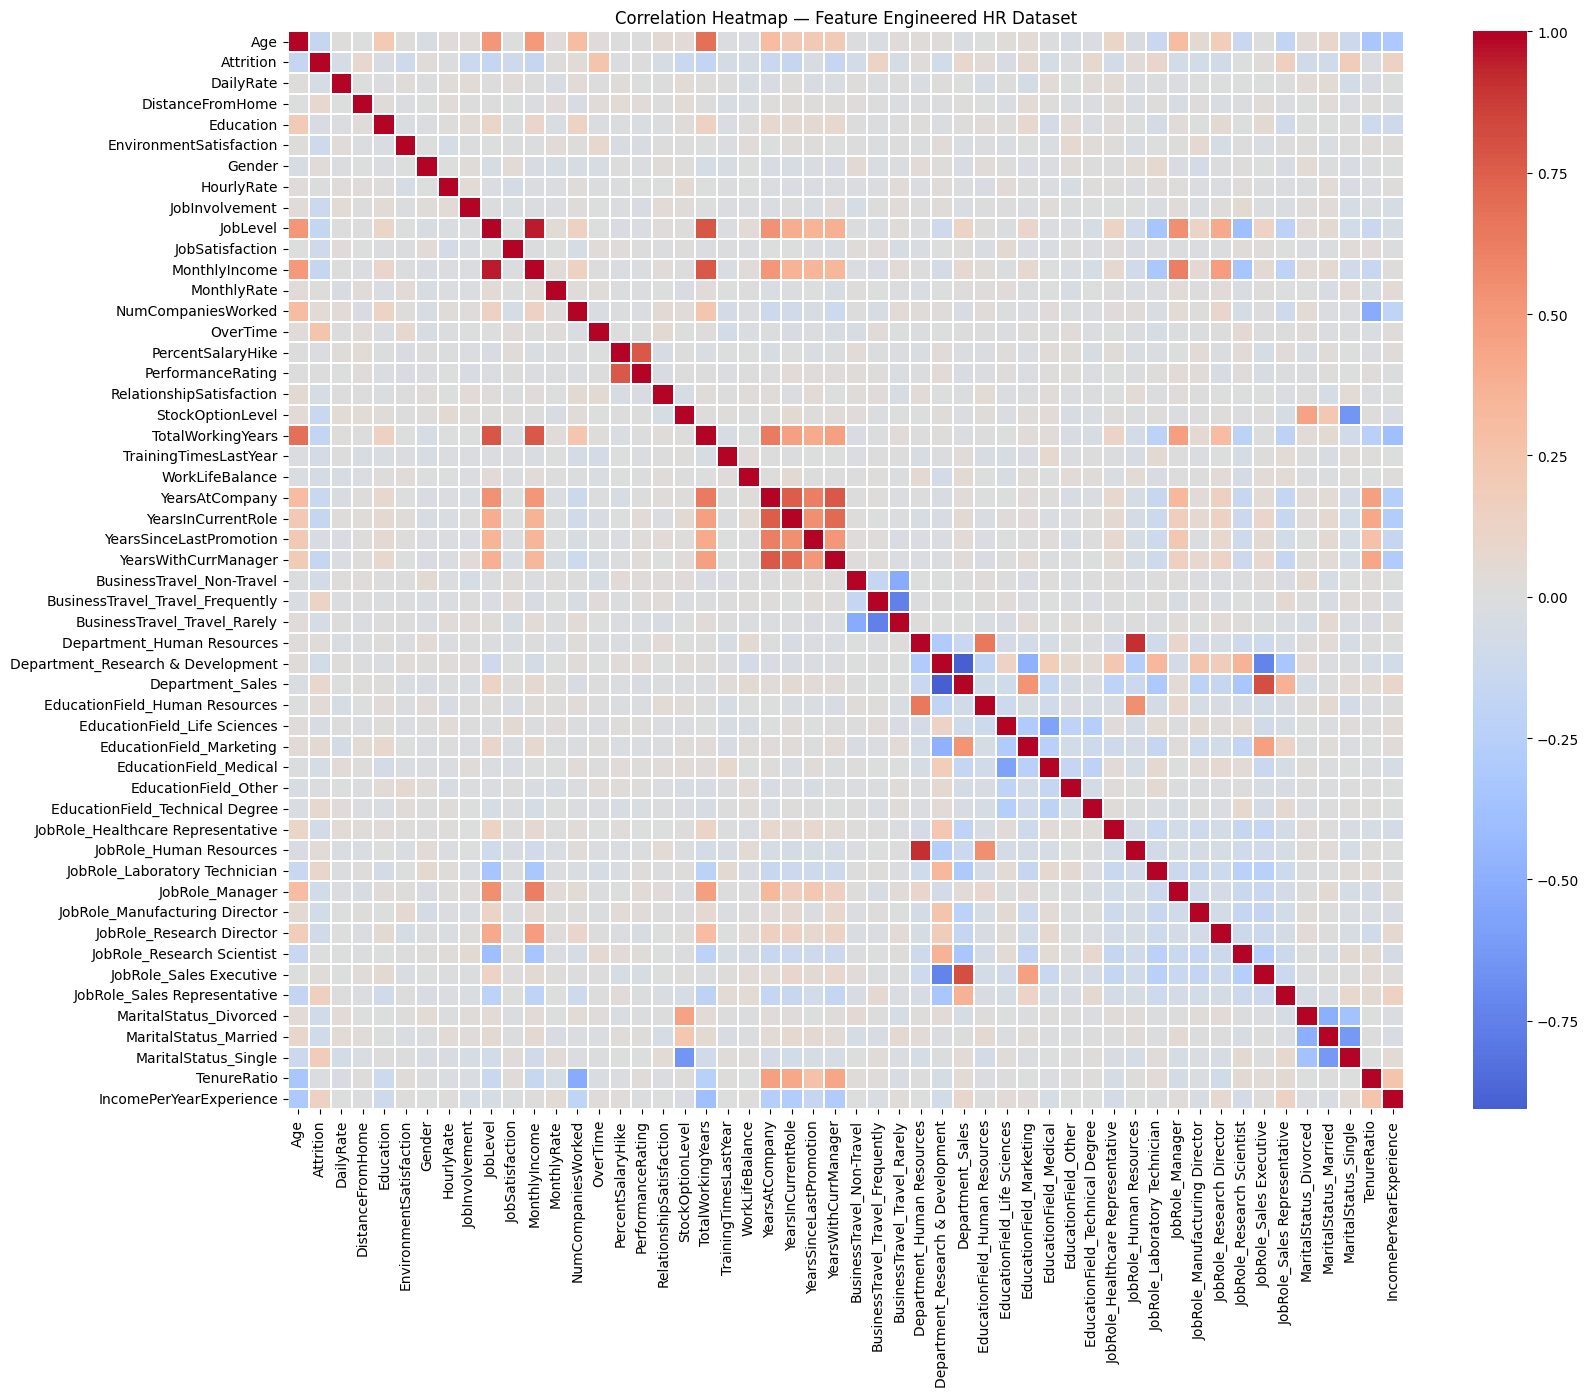

In [ ]:
# Plot correlation heatmap

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title(
    "Correlation Heatmap — Feature Engineered HR Dataset"
)

plt.show()

## 7.5 Highly Correlated Features

To further investigate feature relationships, feature pairs with an absolute correlation of 0.70 or higher are identified.

A high correlation does not automatically mean that a feature must be removed. The relationship and practical meaning of each feature should also be considered.

In [ ]:
# Identify highly correlated feature pairs

corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

high_corr = corr_pairs[
    abs(corr_pairs) >= 0.70
]

print(
    "Highly correlated feature pairs "
    "(|correlation| >= 0.70):"
)

print(high_corr)

Highly correlated feature pairs (|correlation| >= 0.70):
JobLevel                           MonthlyIncome                   0.950300
Department_Human Resources         JobRole_Human Resources         0.904983
Department_Sales                   JobRole_Sales Executive         0.808869
JobLevel                           TotalWorkingYears               0.782208
PercentSalaryHike                  PerformanceRating               0.773550
MonthlyIncome                      TotalWorkingYears               0.772893
YearsAtCompany                     YearsWithCurrManager            0.769212
                                   YearsInCurrentRole              0.758754
YearsInCurrentRole                 YearsWithCurrManager            0.714365
Department_Research & Development  JobRole_Sales Executive        -0.733497
BusinessTravel_Travel_Frequently   BusinessTravel_Travel_Rarely   -0.753092
Department_Research & Development  Department_Sales               -0.906818
dtype: float64


## 7.6 Correlation Analysis Observations

The correlation heatmap provides an overall view of relationships between numerical features.

Features related to employee experience and tenure may show stronger relationships because they measure related aspects of an employee's career history.

The newly created `TenureRatio` and `IncomePerYearExperience` features provide additional information derived from existing employee attributes.

Highly correlated feature pairs were identified using a threshold of |correlation| ≥ 0.70. Correlation alone was not used as the basis for removing features; feature meaning and usefulness were also considered.

## 7.7 Final Feature-Engineered Dataset

After feature engineering and feature selection, the dataset contains the newly created features while irrelevant and redundant columns have been removed.

The resulting dataset is prepared for the next preprocessing stage.

In [ ]:
# Final dataset verification

print("Final feature-engineered dataset")
print("--------------------------------")

print("Rows:", df_fe.shape[0])
print("Columns:", df_fe.shape[1])

print("\nDataset preview:")
display(df_fe.head())

Final feature-engineered dataset
--------------------------------
Rows: 1470
Columns: 52

Dataset preview:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,TenureRatio,IncomePerYearExperience
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0.750000,749.125000
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1.000000,513.000000
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0.000000,298.571429
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1.000000,363.625000
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0.333333,578.000000


In [ ]:
# Save feature-engineered dataset for the next stage

df_fe.to_csv(
    "feature_engineered_hr_data.csv",
    index=False
)

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.


# Train-test split
**Dataset**: IBM HR Analytics Employee Attrition & Performance

**Contribution**: chris

**Objective** :
To fit scaling transformations (StandardScaler or MinMaxScaler) strictly on the training set and apply them to both train and test splits (e.g., MonthlyIncome, Age, DistanceFromHome, TotalWorkingYears). This eliminates scale disparities—preventing high-range features like MonthlyIncome from dominating low-range ones like JobSatisfaction (1–4)—while preventing data leakage between evaluation sets for distance-based machine learning models.


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df[["JobLevel","OverTime","TotalWorkingYears"]]
y=df["Attrition"]

In [ ]:
X.head()

,JobLevel,OverTime,TotalWorkingYears
0,2,1,8
1,2,0,10
2,1,1,7
3,1,1,8
4,1,0,6


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Breakdown

- **Features:** `JobLevel`, `OverTime`, `TotalWorkingYears`
- **Target:** `Attrition` — Binary (`Yes`/`No`)
- **Train/Test Split:** 80% / 20%
- **Random State:** `42`

## Next Steps

- Pass `X_train` and `X_test` to **Feature Scaling/Normalization**.
- Fit the scaler only on `X_train` using `fit_transform()`.
- Apply the scaler to `X_test` using `transform()` to prevent data leakage.
- Pass the processed data to **Model Selection and Training**.

## Conclusion

The dataset was successfully split into **80% training and 20% testing data** using `train_test_split()` with `random_state=42`. This provides separate data for model training and unbiased evaluation, preparing the dataset for **scaling and model development**.

# Feature scaling / normalization
**Dataset**: IBM HR Analytics Employee Attrition & Performance

**Contribution**: Adil

**Objective** :
To scale continuous numeric variables (e.g., MonthlyIncome, Age, DistanceFromHome, TotalWorkingYears) using StandardScaler or MinMaxScaler. This eliminates scale disparities—preventing high-range features like MonthlyIncome from dominating low-range ones like JobSatisfaction (1–4)—and ensures unbiased performance in distance-based machine learning models.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
X_train.describe()

,JobLevel,OverTime,TotalWorkingYears
count,1176.000000,1176.000000,1176.000000
mean,2.028061,0.288265,11.119048
std,1.103215,0.453148,7.814952
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,6.000000
50%,2.000000,0.000000,10.000000
75%,3.000000,1.000000,15.000000
max,5.000000,1.000000,40.000000


In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scale=scaler.fit_transform(X_train)

In [ ]:
#do not use fit transform in test data
X_test_scale=scaler.transform(X_test)

In [ ]:
# Convert back to array if needed and compute along columns (axis=0)
print("Means (should be ~0):", np.round(X_train_scale.mean(axis=0), 2))
print("Std Devs (should be 1):", np.round(X_train_scale.std(axis=0), 2))

Means (should be ~0): [ 0. -0.  0.]
Std Devs (should be 1): [1. 1. 1.]


## Categorical Feature Breakdown

- **Total Categorical Features:** 9 — `Attrition`, `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `Over18`, `OverTime`
- **Binary:** `Attrition`, `Gender`, `OverTime`
- **Ordinal:** `BusinessTravel`
- **Nominal:** `Department`, `EducationField`, `JobRole`, `MaritalStatus`
- **Constant Feature:** `Over18` — contains only `Y`

## Next Steps

- Use the encoded numerical dataset for **feature scaling/normalization**.
- Split data into **training and testing sets** before scaling.
- Apply `StandardScaler` using `fit_transform()` on training data and `transform()` on test data.
- Verify approximately **mean = 0** and **standard deviation = 1**.
- Pass the scaled data to **Model Selection and Training**.

## Conclusion

The categorical features were successfully identified, classified, and encoded into numerical representations suitable for machine learning. The constant `Over18` feature was identified as uninformative. The processed dataset is ready for **feature scaling, model training, and evaluation**.